In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit, cross_validate
from src.ElectricSequentialRegressor import ElectricSequentialRegressor
from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor
from scipy.stats import randint, uniform
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, r2_score, make_scorer
from src.Utils import mse_column_score, plot_performance_analysis, shifted_mape
import joblib

In [2]:
X = pd.read_csv('../dataset/dataset_in.txt', index_col=0).drop(columns=['P2', 'Q2'])
y_columns = [f'V{i}' for i in range(2,15)] + ['PERD', 'QGEN7'] #V1 ES SIEMPRE 1.0 EN DATASET
Y = pd.read_csv('../dataset/dataset_out.txt', index_col=0).loc[:, y_columns]
#FILTRAR DATOS ERRÓNEOS (PÉRDIDAS NEGATIVAS)
mask = Y['PERD'] >= 0
X = X[mask]
Y = Y[mask]
#NORMALIZACIÓN DE ATRIBUTOS PARA FACILITAR COMPARACIÓN ENTRE MODELOS
normalizer_X = MinMaxScaler(feature_range=(0, 1))
X = pd.DataFrame(normalizer_X.fit_transform(X), columns=X.columns, index=X.index)

In [3]:
n_samples = X.shape[0]
train_size = int(n_samples * 0.8)
x_train, y_train = X[:train_size], Y[:train_size]
x_test, y_test = X[train_size:], Y[train_size:]

In [5]:
random_model = ElectricSequentialRegressor(XGBRegressor(objective='reg:squarederror', n_jobs=1, random_state=42), XGBRegressor(objective='reg:squarederror', n_jobs=1, random_state=42), n_jobs=1)
random_grid = {
    'estimator1__n_estimators': randint(30, 101),
    'estimator1__max_depth': randint(3, 9),
    'estimator1__learning_rate': uniform(0.01, 0.2),
    'estimator1__colsample_bytree': uniform(0.4, 0.5),
    'estimator2__n_estimators': randint(80, 251),
    'estimator2__max_depth': randint(4, 11),
    'estimator2__learning_rate': uniform(0.01, 0.2),
    'estimator2__colsample_bytree': uniform(0.4, 0.5)
}
random_scoring = {
    'mse_global': 'neg_mean_squared_error',
    'mse_v_perd': make_scorer(mse_column_score, col_idx=[c for c in range(0, Y.shape[1] - 1)], greater_is_better=False),
    'mse_qgen7': make_scorer(mse_column_score, col_idx=-1, greater_is_better=False),
}
random_search = RandomizedSearchCV(random_model, random_grid, n_iter=30,
                                   cv=TimeSeriesSplit(n_splits=3), scoring=random_scoring, refit='mse_global',
                                   n_jobs=-1, verbose=2, random_state=42, return_train_score=True)

In [6]:
random_search.fit(x_train, y_train)

Fitting 3 folds for each of 30 candidates, totalling 90 fits


,estimator,ElectricSeque... n_jobs=1)
,param_distributions,"{'estimator1__colsample_bytree': <scipy.stats....001307800D3D0>, 'estimator1__learning_rate': <scipy.stats....0013078D2EAD0>, 'estimator1__max_depth': <scipy.stats....001307567B390>, 'estimator1__n_estimators': <scipy.stats....001307568A650>, ...}"
,n_iter,30
,scoring,"{'mse_global': 'neg_mean_squared_error', 'mse_qgen7': make_scorer(m...', col_idx=-1), 'mse_v_perd': make_scorer(m..., 11, 12, 13])}"
,n_jobs,-1
,refit,'mse_global'
,cv,TimeSeriesSpl...est_size=None)
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [7]:
best_random_model = random_search.best_estimator_
print('MSE: ' + str(random_search.best_score_))
random_results = pd.DataFrame(random_search.cv_results_)
random_results.loc[:, ['param_estimator1__max_depth', 'param_estimator1__colsample_bytree', 'param_estimator1__learning_rate', 'param_estimator1__n_estimators', 'param_estimator2__max_depth', 'param_estimator2__colsample_bytree', 'param_estimator2__learning_rate', 'param_estimator2__n_estimators', 'mean_test_mse_global', 'mean_test_mse_v_perd', 'mean_test_mse_qgen7']]

MSE: -0.010193848982453346


,param_estimator1__max_depth,param_estimator1__colsample_bytree,param_estimator1__learning_rate,param_estimator1__n_estimators,param_estimator2__max_depth,param_estimator2__colsample_bytree,param_estimator2__learning_rate,param_estimator2__n_estimators,mean_test_mse_global,mean_test_mse_v_perd,mean_test_mse_qgen7
0,5,0.587270,0.200143,90,10,0.698425,0.099167,154,-0.017284,-0.018496,-0.000315
1,5,0.629624,0.076742,51,9,0.428206,0.154400,117,-0.016207,-0.017340,-0.000341
2,3,0.400389,0.208442,87,4,0.662378,0.096389,138,-0.017698,-0.018938,-0.000338
3,6,0.599930,0.019333,44,6,0.628035,0.167035,187,-0.011974,-0.012748,-0.001137
4,5,0.657117,0.128483,80,5,0.740154,0.100100,211,-0.010554,-0.011286,-0.000314
5,4,0.871101,0.122658,38,7,0.407983,0.056179,190,-0.013805,-0.014767,-0.000332
6,5,0.741632,0.131999,65,9,0.491118,0.161072,213,-0.015844,-0.016953,-0.000314
7,7,0.503971,0.123540,92,5,0.821142,0.099951,93,-0.020316,-0.021744,-0.000320
8,8,0.763636,0.075308,91,5,0.562665,0.087735,190,-0.011680,-0.012492,-0.000312
9,6,0.814369,0.081351,89,10,0.671348,0.038185,124,-0.023591,-0.025254,-0.000307


In [8]:
random_predictions = best_random_model.predict(x_test)
random_MAE = mean_absolute_error(y_test, random_predictions, multioutput='raw_values')
#DESPLAZAMIENTO PARA EVITAR DIVISIÓN POR VALORES CERCANO A 0. CONSECUENCIA: MAPE ALGO OPTIMISTA
random_MAPE = mean_absolute_percentage_error(y_test + 1.0, random_predictions + 1.0, multioutput='raw_values')
random_R2 = r2_score(y_test, random_predictions, multioutput='raw_values')
random_data_score = np.vstack([random_MAE, random_MAPE, random_R2])
evaluations = pd.DataFrame(random_data_score, columns=y_columns, index=['MAE', 'MAPE', 'R2'])
evaluations

,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,PERD,QGEN7
MAE,0.001719,0.001748,0.001792,0.001765,0.001786,0.001733,0.001733,0.001719,0.001733,0.001734,0.001748,0.001611,0.001535,0.250135,0.008766
MAPE,0.000872,0.000887,0.000909,0.000896,0.000906,0.000879,0.000879,0.000872,0.000879,0.000880,0.000887,0.000814,0.000776,0.028839,0.008258
R2,0.972905,0.972508,0.971446,0.972281,0.971730,0.973206,0.973187,0.973644,0.973198,0.973226,0.972827,0.972257,0.974565,0.976682,0.866903


In [9]:
volts_columns = [c for c in y_train.columns if c.startswith('V')]
pd.DataFrame({
    'Voltajes': evaluations[volts_columns].mean(axis=1),
    'Pérdidas': evaluations['PERD'],
    'Potencia Reactiva': evaluations['QGEN7']
})

,Voltajes,Pérdidas,Potencia Reactiva
MAE,0.001720,0.250135,0.008766
MAPE,0.000872,0.028839,0.008258
R2,0.972845,0.976682,0.866903


In [11]:
evaluate_model = ElectricSequentialRegressor(
    XGBRegressor(objective='reg:squarederror', colsample_bytree=0.43, learning_rate=0.2, max_depth=3,
                 n_estimators=37, n_jobs=1, random_state=42),
    XGBRegressor(objective='reg:squarederror', colsample_bytree=0.4, learning_rate=0.173, max_depth=4,
                 n_estimators=215, n_jobs=1, random_state=42))
evaluate_scoring = {
    'mse': 'neg_mean_squared_error',
    'mae': 'neg_mean_absolute_error',
    'mape': make_scorer(shifted_mape, greater_is_better=False),
    'r2': 'r2'
}
evaluate_results = cross_validate(evaluate_model, X, Y, scoring=evaluate_scoring, cv=TimeSeriesSplit(n_splits=5), n_jobs=-1)
print('MSE: ' + str(-evaluate_results['test_mse'].mean()))
print('MAE: ' + str(-evaluate_results['test_mae'].mean()))
print('MAPE: ' + str(-evaluate_results['test_mape'].mean()))
print('R2: ' + str(evaluate_results['test_r2'].mean()))

MSE: 0.011992162838578225
MAE: 0.019367644935846327
MAPE: 0.0033269157769882187
R2: 0.9671599388122558


In [12]:
evaluate_model = ElectricSequentialRegressor(
    XGBRegressor(objective='reg:squarederror', colsample_bytree=0.43, learning_rate=0.2, max_depth=3,
                 n_estimators=37, n_jobs=1, random_state=42),
    XGBRegressor(objective='reg:squarederror', colsample_bytree=0.4, learning_rate=0.173, max_depth=4,
                 n_estimators=215, n_jobs=1, random_state=42), n_jobs=-1)
evaluate_model.fit(x_train, y_train)

,estimator1,"XGBRegressor(...ree=None, ...)"
,estimator2,"XGBRegressor(...ree=None, ...)"
,pivot_col_index,-1
,n_jobs,-1
,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.43


In [13]:
evaluate_predictions = evaluate_model.predict(x_test)
evaluate_MAE = mean_absolute_error(y_test, evaluate_predictions, multioutput='raw_values')
#DESPLAZAMIENTO PARA EVITAR DIVISIÓN POR VALORES CERCANO A 0. CONSECUENCIA: MAPE ALGO OPTIMISTA
evaluate_MAPE = mean_absolute_percentage_error(y_test + 1.0, evaluate_predictions + 1.0, multioutput='raw_values')
evaluate_R2 = r2_score(y_test, evaluate_predictions, multioutput='raw_values')
evaluate_data_score = np.vstack([evaluate_MAE, evaluate_MAPE, evaluate_R2])
evaluations = pd.DataFrame(evaluate_data_score, columns=y_columns, index=['MAE', 'MAPE', 'R2'])
evaluations

,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,PERD,QGEN7
MAE,0.001720,0.001749,0.001796,0.001764,0.001782,0.001732,0.001736,0.001719,0.001734,0.001733,0.001746,0.001608,0.001536,0.250756,0.008905
MAPE,0.000872,0.000887,0.000911,0.000895,0.000904,0.000879,0.000881,0.000872,0.000880,0.000879,0.000886,0.000813,0.000776,0.028991,0.008388
R2,0.972866,0.972512,0.971431,0.972261,0.971877,0.973220,0.973191,0.973622,0.973228,0.973262,0.972901,0.972278,0.974547,0.976738,0.866425


In [14]:
volts_columns = [c for c in y_train.columns if c.startswith('V')]
pd.DataFrame({
    'Voltajes': evaluations[volts_columns].mean(axis=1),
    'Pérdidas': evaluations['PERD'],
    'Potencia Reactiva': evaluations['QGEN7']
})

,Voltajes,Pérdidas,Potencia Reactiva
MAE,0.001720,0.250756,0.008905
MAPE,0.000872,0.028991,0.008388
R2,0.972861,0.976738,0.866425


In [15]:
joblib.dump(evaluate_model, '../models/ESR_MO_XGBoost.pkl')

['../models/ESR_MO_XGBoost.pkl']

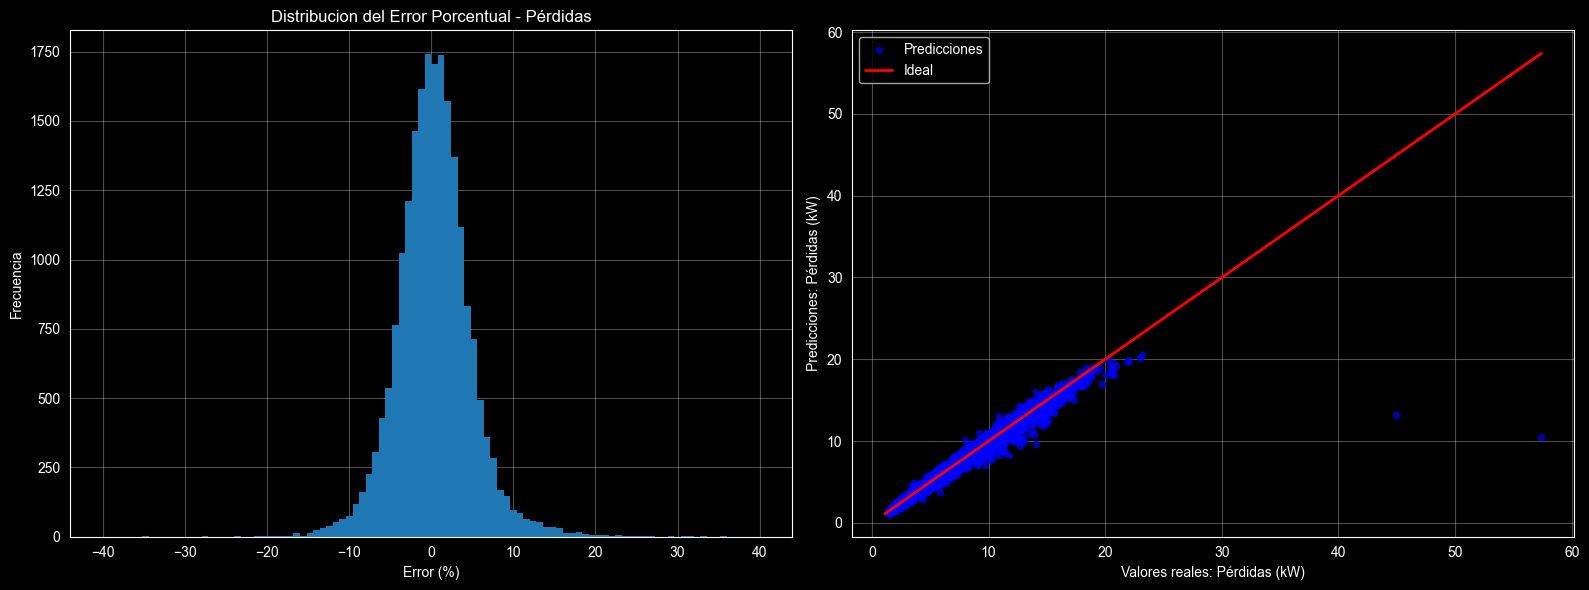

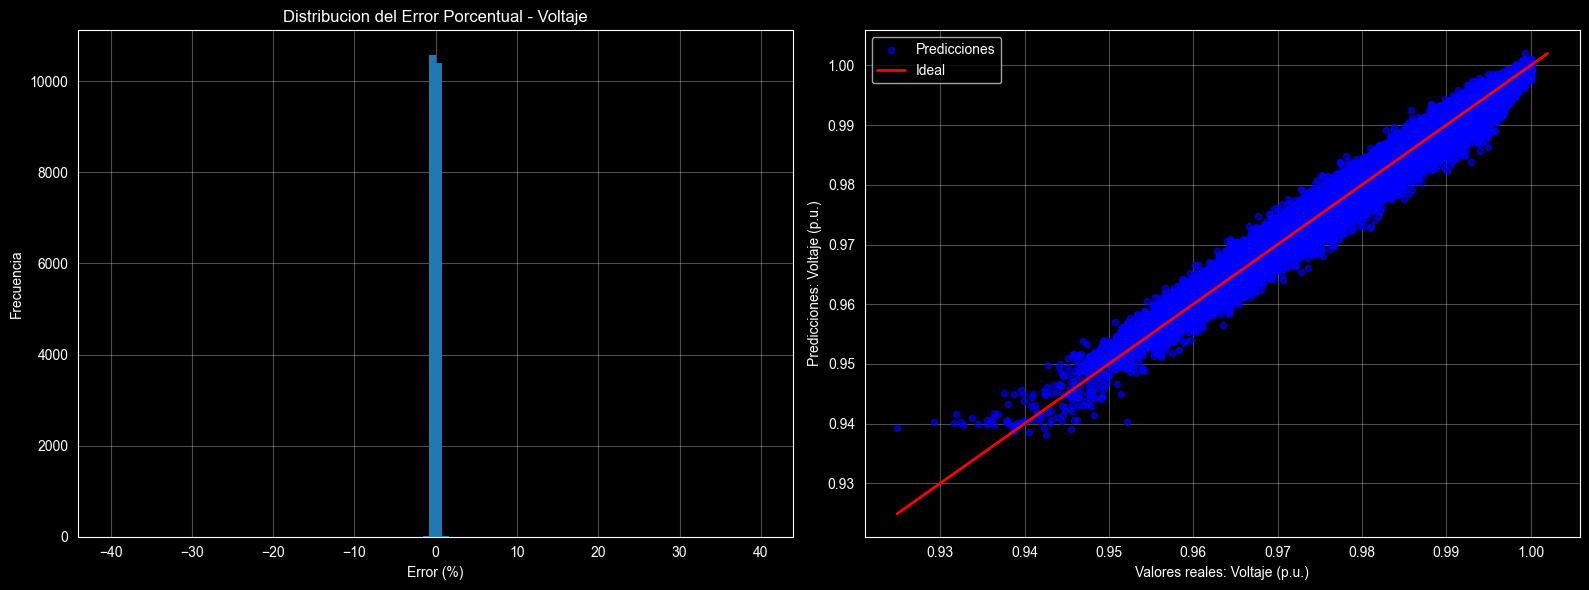

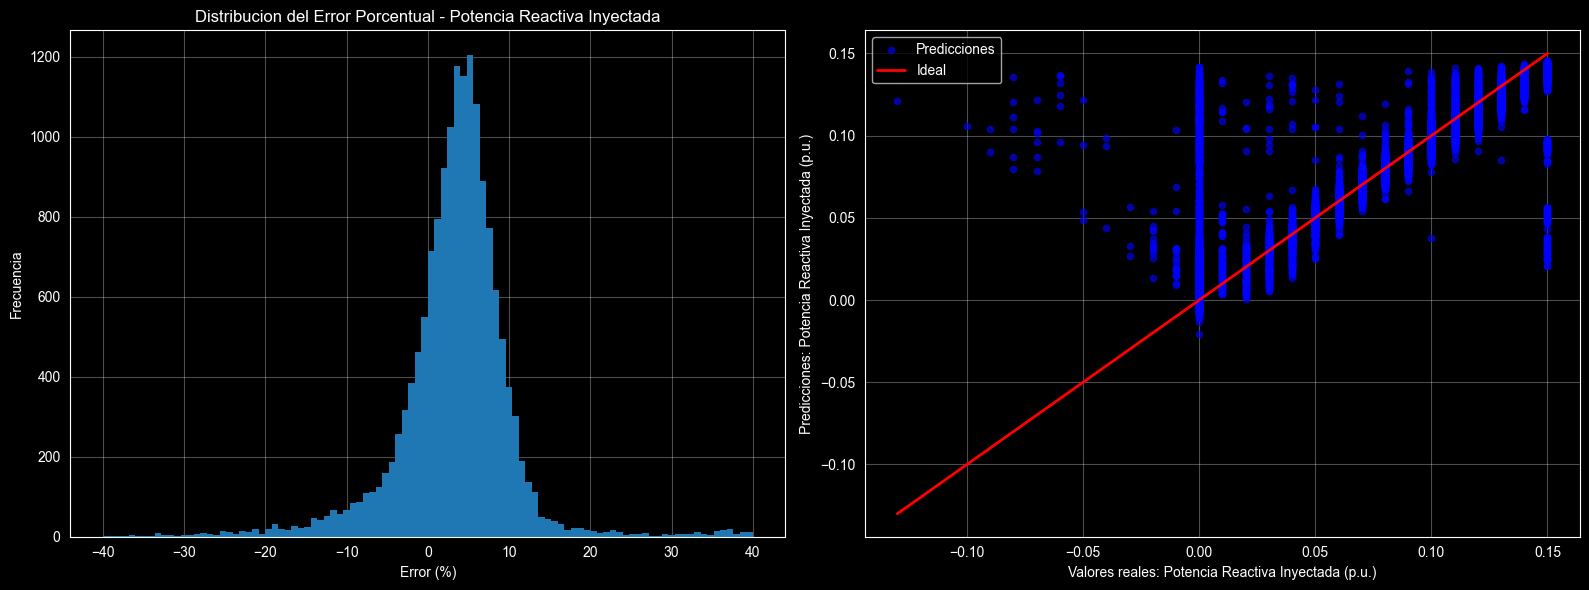

In [16]:
plot_performance_analysis(
    y_test['PERD'],
    random_predictions[:, -2],
    variable_name="Pérdidas",
    unit_label="kW",
    path='../figures/XGBoost/ESR_MO_XGBoost_Perd.png'
)
plot_performance_analysis(
    y_test['V13'],
    random_predictions[:, -4],
    variable_name="Voltaje",
    unit_label="p.u.",
    path='../figures/XGBoost/ESR_MO_XGBoost_V13.png'
)
plot_performance_analysis(
    y_test['QGEN7'],
    random_predictions[:, -1],
    variable_name="Potencia Reactiva Inyectada",
    unit_label="p.u.",
    path='../figures/XGBoost/ESR_MO_XGBoost_QGen.png'
)